In [ ]:
from sklearn.model_selection import train_test_split
from pyoperon.sklearn import SymbolicRegressor  # pip install pyoperon
import pandas as pd
import matplotlib.pyplot as plt
import sympy as sp
import numpy as np

class SR:
    def __init__(self, x_values, y_values, x_true, y_true, optimizer_iterations=20, max_length=20, population_size=10_000, generations=10_000, seed=42):
        self.X_train = x_values
        self.y_train = y_values
        self.X_test = x_true
        self.y_test = y_true
        self.optimizer_iterations = optimizer_iterations
        self.max_length = max_length
        self.population_size = population_size
        self.generations = generations
        self.seed = seed

        # Splitting data into train and test data
        self.X_train, self.X_test, self.y_train, self.y_test = train_test_split(x_values, y_values, test_size=0.2, random_state=self.seed)

        # Create a SymbolicRegressor object and use its sklearn-like interface
        self.reg = SymbolicRegressor(
                allowed_symbols='add,sub,mul,div,pow,cos,sin,exp,constant,variable',
                optimizer_iterations=self.optimizer_iterations,
                max_length=self.max_length,
                n_threads=8,
                objectives = ['r2'],
                population_size=self.population_size,
                generations=self.generations,
                random_state=self.seed,
                epsilon=0.001
            )
        
    def train(self):
        self.reg.fit(self.X_train, self.y_train)
        best_model = self.reg.get_model_string(self.reg.model_, precision=5) 
        self.best_model_simple = sp.simplify(best_model) 

        print("R2 train:   ", self.reg.score(self.X_train,self.y_train))
        print("R2 test:    ", self.reg.score(self.X_test,self.y_test))
        print("Best model: ", best_model)
        print("Best model simple: ", self.best_model_simple)

        return self.best_model_simple
    
    def make_symbolic_function(self): 
        variables = ["X1", "X2", "X3", "X4", "X5", "X6", "X7", "X8", "X9", "X10", "X11", "X12", "X13", "X14", "X15", "X16", "X17", "X18", "X19", "X20"] 
        expr = self.best_model_simple
        expr = str(expr)
        expr = expr.replace("^", "**")
        expr = expr.replace("sqrt", "np.sqrt")
        expr = expr.replace("sin", "np.sin")
        expr = expr.replace("cos", "np.cos")
        expr = expr.replace("tan", "np.tan")
        expr = expr.replace("log", "np.log")
        expr = expr.replace("exp", "np.exp")

        # Safe eval with numpy
        def func(**kwargs):
            return eval(expr, {"__builtins__": {},"np": np}, kwargs)

        return func

    def predict(self, x):
        func = self.make_symbolic_function()
        return func(X1=x[0],X2=x[1],X3=x[2],X4=x[3],X5=x[4],X6=x[5],X7=x[6],X8=x[7],X9=x[8],X10=x[9],X11=x[10],X12=x[11],X13=x[12],X14=x[13],X15=x[14],X16=x[15],X17=x[16],X18=x[17],X19=x[18],X20=x[19])

In [ ]:
# Data and features
df = pd.read_csv("/home/simonmadsen/SummerSchool26/international-summer-school-robotics-TER-UR/case 2/data/test-4.csv")

cols_x = ["target_q0","target_q1","target_q2","target_q3","target_q4","target_q5","target_qd0","target_qd1","target_qd2","target_qd3","target_qd4","target_qd5","target_qdd0","target_qdd1","target_qdd2","target_qdd3","target_qdd4","target_qdd5","vel","acc"]
cols_y = ["actual_q1"]


# Add time lags
lags = [1, 2, 3] # More is NOT better (i.e. 5 and 10)

for col in cols_x:
    for lag in lags:
        df[f"{col}_lag{lag}"] = df[col].shift(lag)

df = df.dropna()

# # Add jerk
# for i in range(6):
#     df[f"target_jerk{i}"] = np.gradient(df[f"target_qdd{i}"])


# Create new features
feature_cols = [
    col for col in df.columns
    if col.startswith("target_")
    or "_lag" in col
]


# Training
target_position = df["target_q1"].to_numpy()
actual_position = df["actual_q1"].to_numpy()
position_error = target_position - actual_position

X = df[feature_cols]
y = df[cols_y]

sr = SR(X,y,None,None)
sr.train()

/home/simonmadsen/miniforge3/envs/datasim/lib/python3.12/site-packages/sklearn/utils/validation.py:1406: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [ ]:
# Training
target_position = df["target_q1"].to_numpy()
actual_position = df["actual_q1"].to_numpy()
position_error = target_position - actual_position

X = df[feature_cols]
y = df[cols_y]

sr = SR(X,y,None,None)
sr.train()

In [87]:
# Predicting
predicted_position = sr.reg.predict(X)

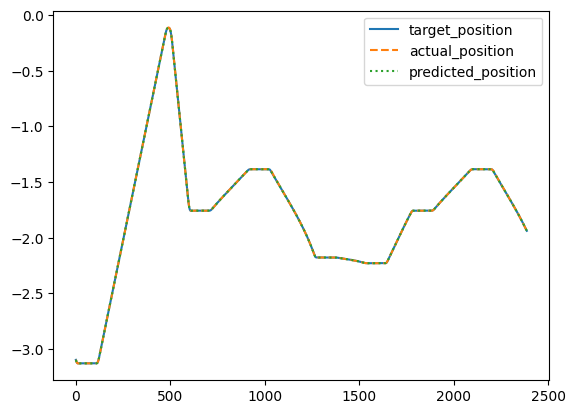

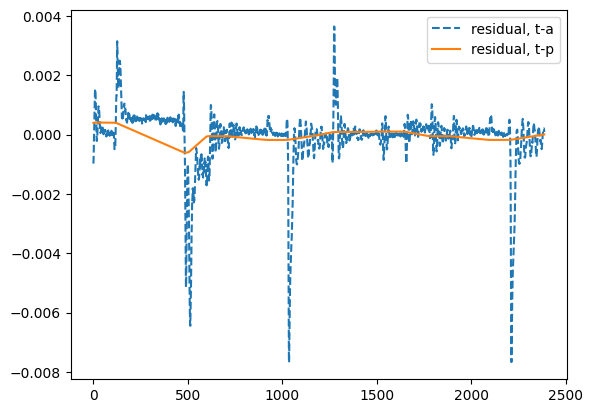

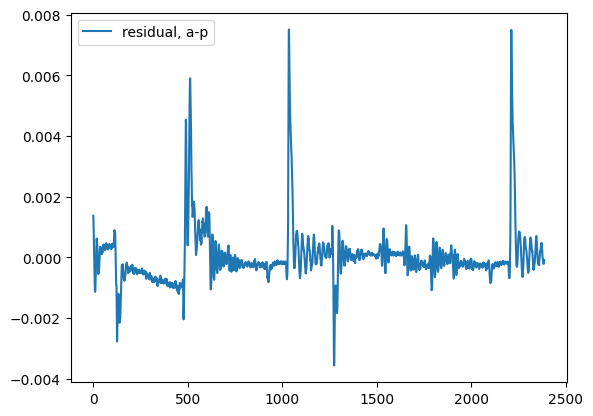

In [ ]:
n = 25

# Plotting
plt.figure()
plt.plot(target_position[(n)*2388:(n+1)*2388], label = "target_position")
plt.plot(actual_position[(n)*2388:(n+1)*2388], linestyle = '--', label = "actual_position")
plt.plot(predicted_position[(n)*2388:(n+1)*2388], linestyle = ':', label = "predicted_position")
plt.legend()

plt.figure()
plt.plot((target_position[(n)*2388:(n+1)*2388] - actual_position[(n)*2388:(n+1)*2388]), linestyle = "--", label = "residual, t-a")
plt.plot((target_position[(n)*2388:(n+1)*2388] - predicted_position[(n)*2388:(n+1)*2388]), label = "residual, t-p")
plt.legend()

plt.figure()
plt.plot(actual_position[(n)*2388:(n+1)*2388] - predicted_position[(n)*2388:(n+1)*2388], label = "residual, a-p")
plt.legend()